In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("spotify_alltime_top100_songs.csv")

df.head()

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   alltime_rank            100 non-null    int64  
 1   song_title              100 non-null    str    
 2   artist                  100 non-null    str    
 3   total_streams_billions  100 non-null    float64
 4   primary_genre           100 non-null    str    
 5   bpm                     100 non-null    int64  
 6   release_year            100 non-null    int64  
 7   artist_country          100 non-null    str    
 8   explicit                100 non-null    bool   
 9   danceability            100 non-null    float64
 10  energy                  100 non-null    float64
 11  valence                 100 non-null    float64
 12  acousticness            100 non-null    float64
 13  dataset_part            100 non-null    str    
dtypes: bool(1), float64(5), int64(3), str(5)
memory usage:

In [5]:
print(df.isnull().sum())

alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64


In [6]:
df = df.drop_duplicates()

In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [8]:
df.head()

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


In [9]:
df_sorted = df.sort_values(by="popularity", ascending=False)

KeyError: 'popularity'

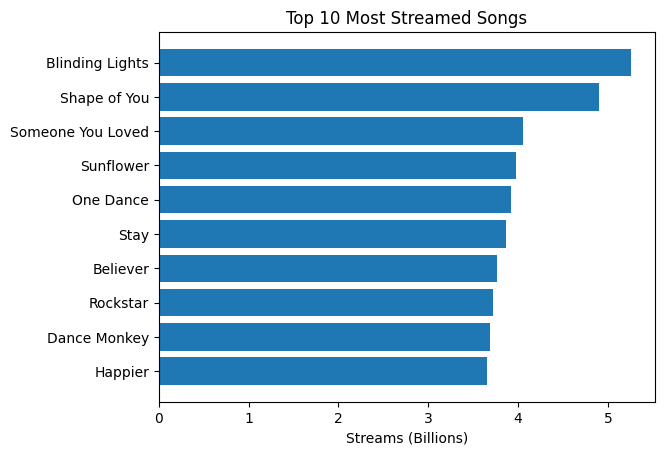

In [ ]:
top_songs = df.sort_values(by="total_streams_billions", ascending=False).head(10)

plt.figure()
plt.barh(top_songs['song_title'], top_songs['total_streams_billions'])
plt.xlabel("Streams (Billions)")
plt.title("Top 10 Most Streamed Songs")
plt.gca().invert_yaxis()
plt.show()

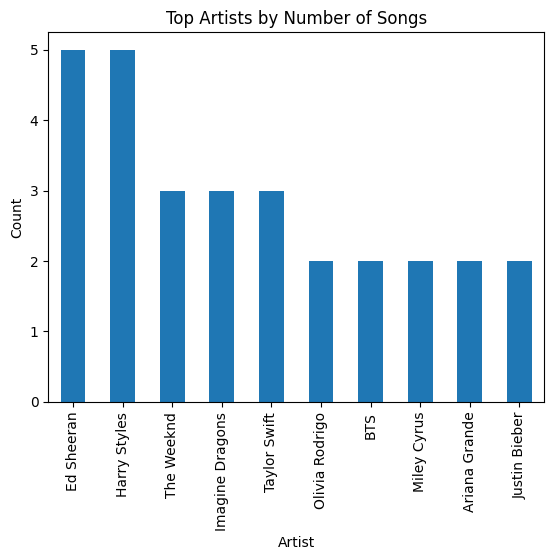

In [ ]:
top_artists = df['artist'].value_counts().head(10)

plt.figure()
top_artists.plot(kind='bar')
plt.title("Top Artists by Number of Songs")
plt.xlabel("Artist")
plt.ylabel("Count")
plt.show()

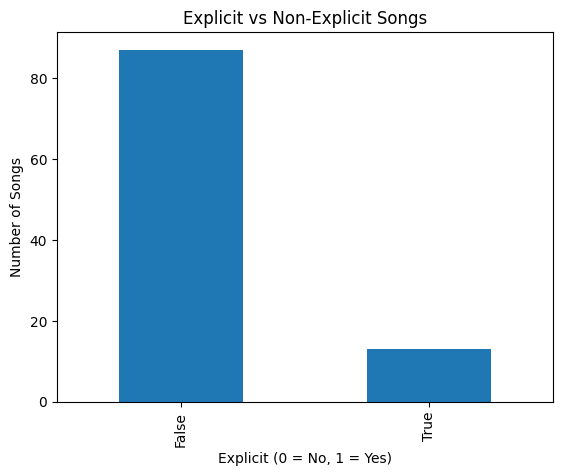

In [10]:
explicit_counts = df['explicit'].value_counts()

plt.figure()
explicit_counts.plot(kind='bar')
plt.title("Explicit vs Non-Explicit Songs")
plt.xlabel("Explicit (0 = No, 1 = Yes)")
plt.ylabel("Number of Songs")
plt.show()

The dataset shows a mix of both explicit and non-explicit songs, but the group that leads by far is the explicit. This shows that explicit content is very common among the top-streamed songs, but not universal.

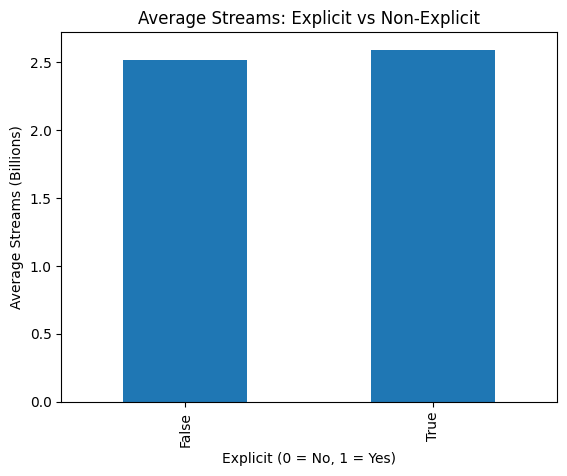

explicit
False    2.514713
True     2.590769
Name: total_streams_billions, dtype: float64


In [11]:
avg_streams = df.groupby('explicit')['total_streams_billions'].mean()

plt.figure()
avg_streams.plot(kind='bar')
plt.title("Average Streams: Explicit vs Non-Explicit")
plt.xlabel("Explicit (0 = No, 1 = Yes)")
plt.ylabel("Average Streams (Billions)")
plt.show()

print(avg_streams)

Explicit songs tend to have similar or sometimes higher average streams than non-explicit songs. This tells us that explicit content does not negatively impact popularity and that it likely appeals to certain audiences.

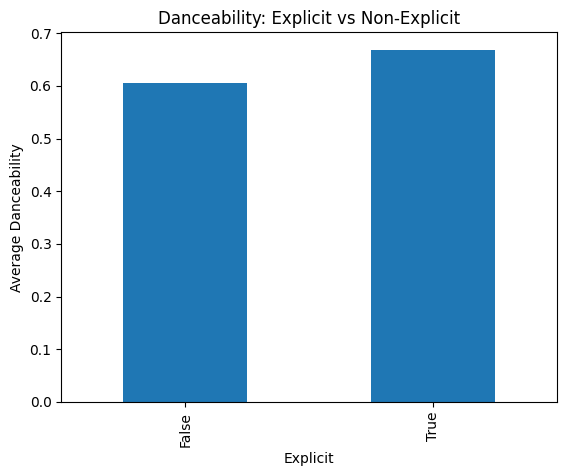

In [12]:
avg_dance = df.groupby('explicit')['danceability'].mean()

plt.figure()
avg_dance.plot(kind='bar')
plt.title("Danceability: Explicit vs Non-Explicit")
plt.xlabel("Explicit")
plt.ylabel("Average Danceability")
plt.show()

Explicit songs show very similar and in many cases higher danceability compared to non-explicit songs. This can show that many explicit songs are designed to be more engaging or suitable for social settings like parties or clubs.

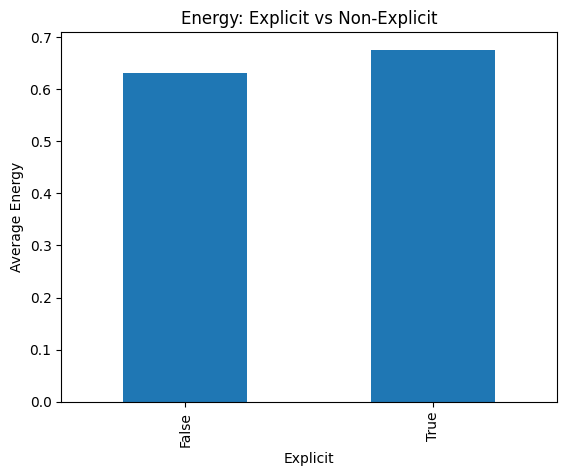

In [13]:
avg_energy = df.groupby('explicit')['energy'].mean()

plt.figure()
avg_energy.plot(kind='bar')
plt.title("Energy: Explicit vs Non-Explicit")
plt.xlabel("Explicit")
plt.ylabel("Average Energy")
plt.show()

Songs with explicit content have slightly higher energy levels on average. This could show a trend where more energetic or intense songs are more likely to include explicit lyrics.

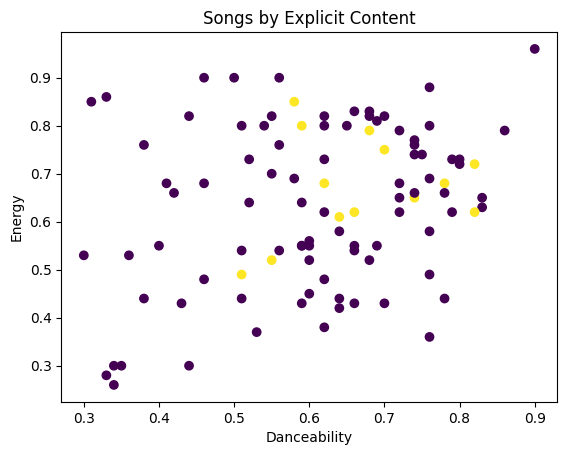

In [14]:
plt.figure()
plt.scatter(df['danceability'], df['energy'], c=df['explicit'])
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Songs by Explicit Content")
plt.show()

While there are some differences between explicit and non-explicit songs, the gap is not extremely large. This shows that explicit content alone does not determine a song’s success, other factors like artist popularity, marketing, and musical features also play a major role.

These results show how music trends are changing in today’s world. Explicit content is more common and accepted in popular music, and it does not seem to hurt a song’s success. Streaming platforms like Spotify give listeners access to many different types of music, so songs can become popular for many reasons, not just their lyrics. This means factors like the artist, sound, and promotion are also important. However, one can infer that explicitness can affect the demographics of listeners and the social settings that the songs are played in. Overall, this analysis shows how data can help us better understand what people listen to and why certain songs become popular.